## SHRINKAGE METHODS

In [23]:
# Load required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### usiamo i dati engineered con log-price

In [24]:
data=pd.read_csv("Data/aircraft_price_cleaned_log.csv")
data.columns

Index(['model_name', 'engine_type', 'engine_power', 'max_speed',
       'cruise_speed', 'stall_speed', 'fuel_tank', 'all_eng_roc',
       'out_eng_roc', 'takeoff_distance', 'landing_distance', 'empty_weight',
       'length', 'wing_span', 'range', 'price'],
      dtype='object')

In [10]:
numeric_data=data.select_dtypes(include=[np.number])
numeric_data

,engine_power,max_speed,cruise_speed,stall_speed,fuel_tank,all_eng_roc,out_eng_roc,takeoff_distance,landing_distance,empty_weight,length,wing_span,range,price
0,4.976734,4.644391,4.510860,46.0,3.583519,6.109248,6.802395,7.170120,7.625595,7.073270,5.713733,6.107023,5.913503,14.077875
1,4.442651,4.488636,4.418841,44.0,2.708050,6.396930,6.579251,6.684612,7.207860,6.709304,5.509388,6.070738,5.247024,14.022525
2,4.499810,4.499810,4.356709,37.0,2.944439,6.476972,6.163315,6.745236,7.170120,6.697034,5.549076,6.040255,5.347108,14.285514
3,4.442651,4.477337,4.356709,37.0,2.944439,6.429719,6.214608,6.745236,7.170120,6.684612,5.549076,6.040255,5.347108,14.077875
4,4.174387,4.418841,4.304065,33.0,2.639057,5.913503,6.448889,6.785588,7.106606,6.606650,5.549076,6.040255,5.164786,14.038654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,6.907755,5.860786,5.811141,56.0,8.247744,8.083946,7.565275,7.731931,9.396820,8.969033,6.255750,6.349139,7.538495,15.226498
503,6.579251,5.743003,5.662960,89.0,6.359574,7.774856,7.731931,8.020599,9.323669,8.830104,6.255750,6.349139,7.451242,15.091990
504,6.579251,5.669881,5.616771,87.0,5.966147,7.712444,8.080237,8.012018,9.323669,8.762333,6.255750,6.349139,7.323171,14.978661
505,6.429719,5.616771,5.598422,77.0,5.945421,7.467371,7.986165,7.802209,9.156306,8.549467,6.086775,6.238325,7.197435,14.991084


In [11]:
# Data exploration
print(f"Dataset shape: {data.shape}")
print(f"Features: {data.shape[1]}")
print(f"Target variable (log-price) statistics:")
print(y.describe())

# Prepare features and target
X = pd.get_dummies(data.drop('price', axis=1), drop_first=True)
y = data['price']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Define lambda values for regularization
lambda_values = np.logspace(-2, 3, 150)

Dataset shape: (507, 16)
Features: 16
Target variable (log-price) statistics:
count    507.000000
mean      14.589019
std        0.412730
min       13.384728
25%       14.285514
50%       14.508658
75%       14.897316
max       15.444751
Name: price, dtype: float64

Training set: 253 samples
Test set: 254 samples


In [12]:
# Create Ridge pipeline with scaling
pipeline = make_pipeline(StandardScaler(), Ridge())

# Grid search for best alpha
param_grid = {'ridge__alpha': lambda_values}
ridge_cv = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=10)
ridge_cv.fit(X_train, y_train)
best_alpha = ridge_cv.best_params_['ridge__alpha']
print(f"Best Ridge alpha: {best_alpha}")

Best Ridge alpha: 13.207036227366311


In [13]:
# Evaluate Ridge on test set with multiple metrics
ridge_best = make_pipeline(StandardScaler(), Ridge(alpha=best_alpha))
ridge_best.fit(X_train, y_train)
ridge_pred = ridge_best.predict(X_test)

# Calculate multiple metrics
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("=== RIDGE REGRESSION RESULTS ===")
print(f"Best alpha: {best_alpha:.4f}")
print(f"Test MSE: {ridge_mse:.4f}")
print(f"Test RMSE: {ridge_rmse:.4f}")
print(f"Test MAE: {ridge_mae:.4f}")
print(f"Test R²: {ridge_r2:.4f}")

# Store results for comparison
ridge_results = {
    'alpha': best_alpha,
    'mse': ridge_mse,
    'rmse': ridge_rmse,
    'mae': ridge_mae,
    'r2': ridge_r2,
    'predictions': ridge_pred
}

=== RIDGE REGRESSION RESULTS ===
Best alpha: 13.2070
Test MSE: 0.0249
Test RMSE: 0.1579
Test MAE: 0.1182
Test R²: 0.8584


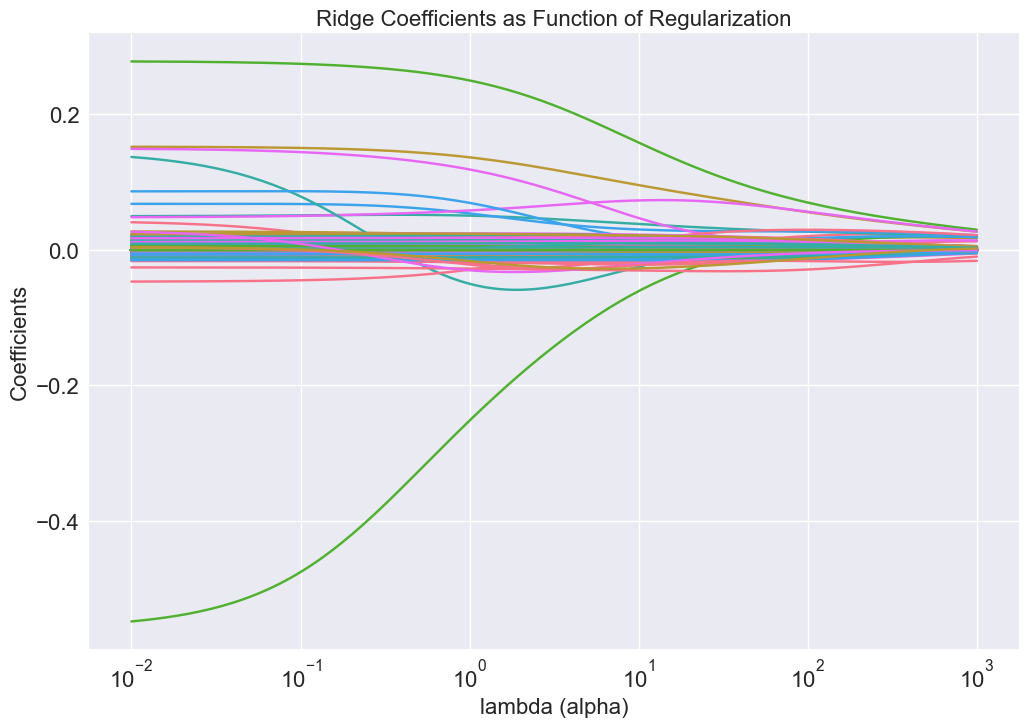

In [25]:
# Plot coefficients vs lambda
coefs = []
for a in lambda_values:
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=a))
    pipe.fit(X_train, y_train)
    coefs.append(pipe.named_steps['ridge'].coef_)

plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.plot(lambda_values, coefs)
ax.set_xscale('log')
plt.xlabel('lambda (alpha)', fontsize=16)
plt.ylabel('Coefficients', fontsize=16)
plt.title('Ridge Coefficients as Function of Regularization', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

Stai osservando come Ridge "controlla" i coefficienti al crescere della regolarizzazione: li rende piccoli, ma non li azzera — e questo è esattamente il comportamento previsto.

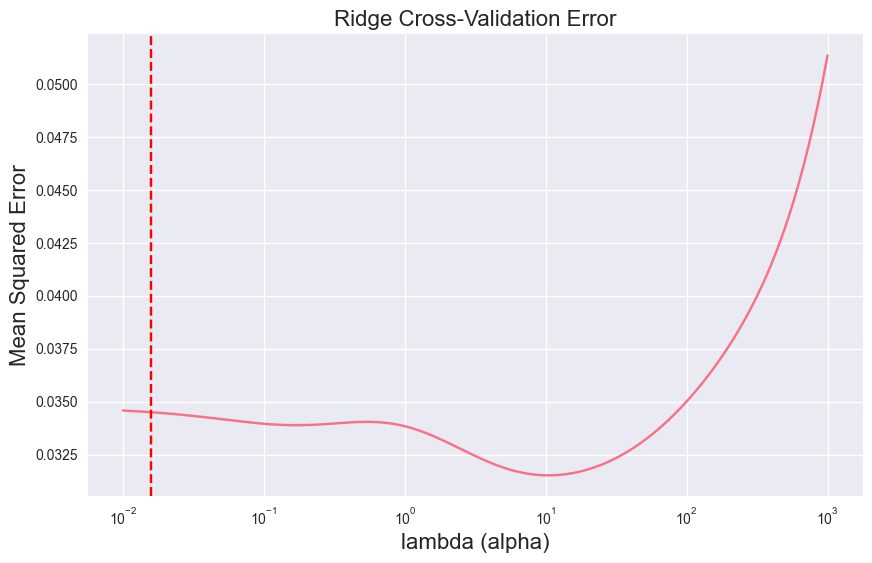

In [26]:
# Plot cross-validation errors
cv_scores = []
for alpha in lambda_values:
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    kf = KFold(n_splits=10, shuffle=True, random_state=1)
    scores = -cross_val_score(pipe, X_train, y_train, cv=kf, 
                             scoring='neg_mean_squared_error')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.semilogx(lambda_values, cv_scores)
plt.axvline(best_alpha, color='r', linestyle='--')
plt.xlabel('lambda (alpha)',fontsize=16)
plt.ylabel('Mean Squared Error',fontsize=16)
plt.title('Ridge Cross-Validation Error',fontsize=16)
plt.show()

## LASSO 

In [16]:
# Create Lasso pipeline with scaling
lasso_pipe = make_pipeline(StandardScaler(), Lasso(max_iter=10000))


# Grid search for best alpha
lasso_cv = GridSearchCV(lasso_pipe, 
                       {'lasso__alpha': lambda_values},
                       scoring='neg_mean_squared_error',
                       cv=10)
lasso_cv.fit(X_train, y_train)
best_alpha = lasso_cv.best_params_['lasso__alpha']
print(f"Best Lasso alpha: {best_alpha}")

Best Lasso alpha: 0.015897992284504753


In [17]:
# Evaluate Lasso on test set with multiple metrics
lasso_best = lasso_cv.best_estimator_
lasso_pred = lasso_best.predict(X_test)

# Calculate multiple metrics
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

# Number of non-zero coefficients
final_coefs = lasso_best.named_steps['lasso'].coef_
n_selected = np.sum(final_coefs != 0)

print("=== LASSO REGRESSION RESULTS ===")
print(f"Best alpha: {lasso_cv.best_params_['lasso__alpha']:.4f}")
print(f"Test MSE: {lasso_mse:.4f}")
print(f"Test RMSE: {lasso_rmse:.4f}")
print(f"Test MAE: {lasso_mae:.4f}")
print(f"Test R²: {lasso_r2:.4f}")
print(f"Selected features: {n_selected}/{len(final_coefs)} ({n_selected/len(final_coefs)*100:.1f}%)")

# Store results for comparison
lasso_results = {
    'alpha': lasso_cv.best_params_['lasso__alpha'],
    'mse': lasso_mse,
    'rmse': lasso_rmse,
    'mae': lasso_mae,
    'r2': lasso_r2,
    'n_features': n_selected,
    'predictions': lasso_pred
}

=== LASSO REGRESSION RESULTS ===
Best alpha: 0.0159
Test MSE: 0.0257
Test RMSE: 0.1604
Test MAE: 0.1192
Test R²: 0.8539
Selected features: 16/290 (5.5%)


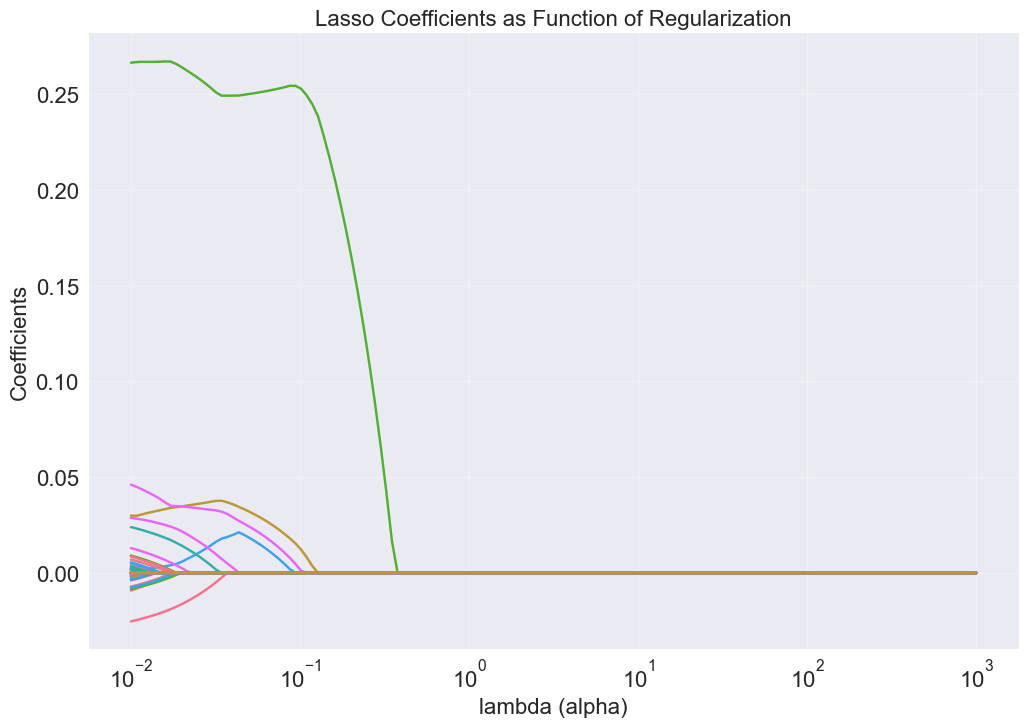

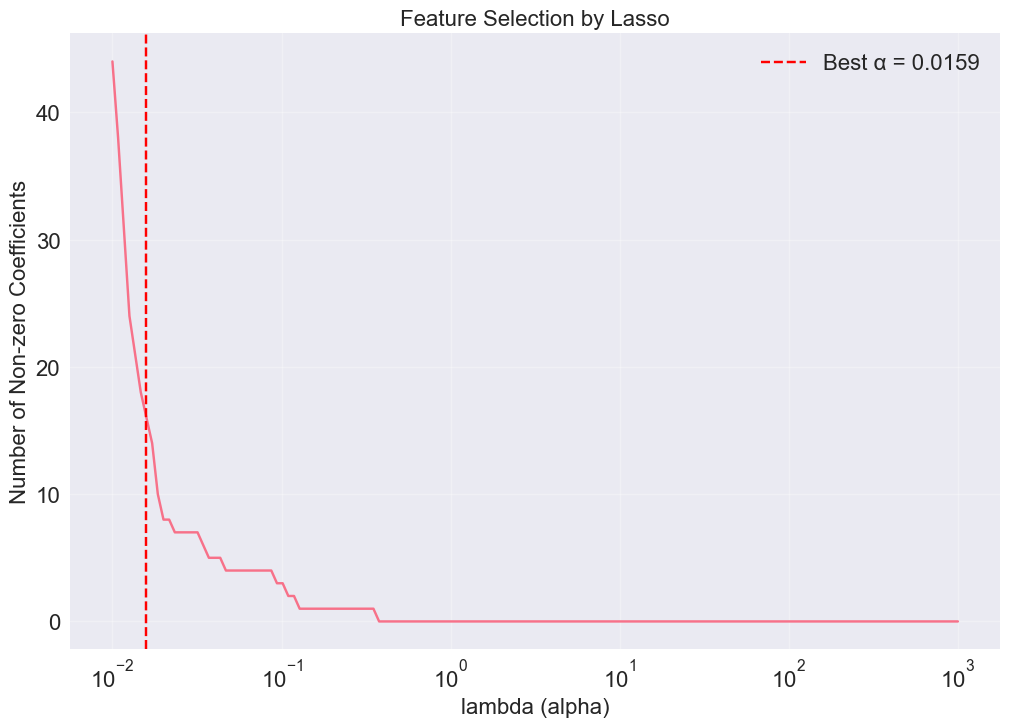

In [30]:
# Plot Lasso coefficients for different lambda values
coefs = []
for a in lambda_values:
    pipe = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000))
    pipe.fit(X_train, y_train)
    coefs.append(pipe.named_steps['lasso'].coef_)

# Plot 1: All coefficients
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.plot(lambda_values, coefs)
ax.set_xscale('log')
plt.xlabel('lambda (alpha)', fontsize=16)
plt.ylabel('Coefficients', fontsize=16)
plt.title('Lasso Coefficients as Function of Regularization', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Number of non-zero coefficients
n_nonzero = [np.sum(c != 0) for c in coefs]
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.semilogx(lambda_values, n_nonzero)
ax.set_xlabel('lambda (alpha)', fontsize=16)
ax.set_ylabel('Number of Non-zero Coefficients', fontsize=16)
ax.set_title('Feature Selection by Lasso', fontsize=16)
ax.grid(True, alpha=0.3)
ax.axvline(lasso_results['alpha'], color='r', linestyle='--', label=f'Best α = {lasso_results["alpha"]:.4f}')
ax.legend(fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()



## CONFRONTO TRA RIDGE E LASSO

=== CONFRONTO RIDGE vs LASSO ===
Metric          Ridge        Lasso        Difference  
-------------------------------------------------------
MSE             0.0249       0.0257       -0.0008     
RMSE            0.1579       0.1604       -0.0025     
MAE             0.1182       0.1192       -0.0010     
R²              0.8584       0.8539       0.0045      
Features        290          16           274         
Alpha           13.2070      0.0159       -


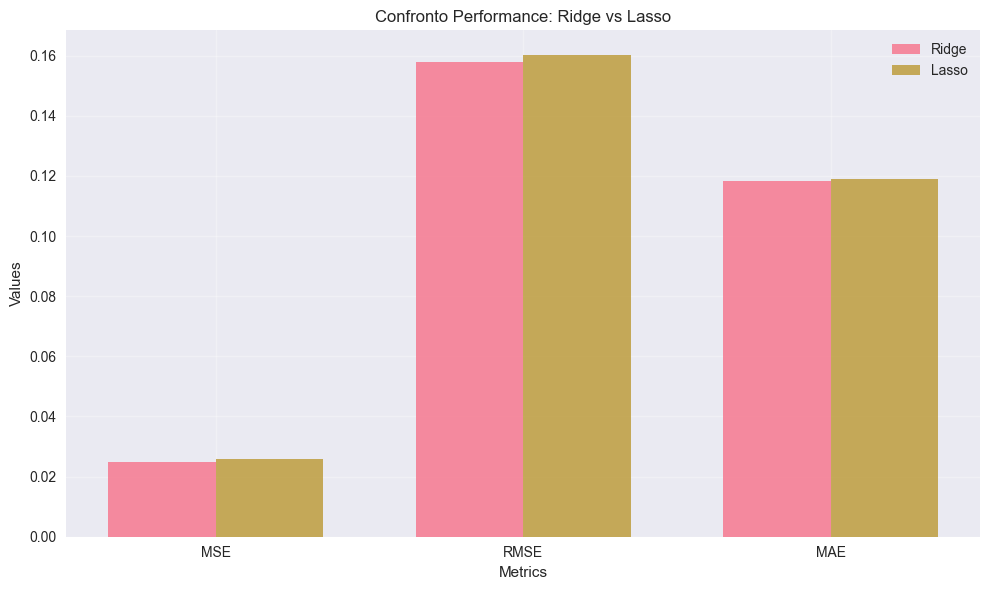

In [19]:
# Confronto delle performance tra Ridge e Lasso
print("=== CONFRONTO RIDGE vs LASSO ===")
print(f"{'Metric':<15} {'Ridge':<12} {'Lasso':<12} {'Difference':<12}")
print("-" * 55)
print(f"{'MSE':<15} {ridge_results['mse']:<12.4f} {lasso_results['mse']:<12.4f} {ridge_results['mse'] - lasso_results['mse']:<12.4f}")
print(f"{'RMSE':<15} {ridge_results['rmse']:<12.4f} {lasso_results['rmse']:<12.4f} {ridge_results['rmse'] - lasso_results['rmse']:<12.4f}")
print(f"{'MAE':<15} {ridge_results['mae']:<12.4f} {lasso_results['mae']:<12.4f} {ridge_results['mae'] - lasso_results['mae']:<12.4f}")
print(f"{'R²':<15} {ridge_results['r2']:<12.4f} {lasso_results['r2']:<12.4f} {ridge_results['r2'] - lasso_results['r2']:<12.4f}")
print(f"{'Features':<15} {X.shape[1]:<12} {lasso_results['n_features']:<12} {X.shape[1] - lasso_results['n_features']:<12}")
print(f"{'Alpha':<15} {ridge_results['alpha']:<12.4f} {lasso_results['alpha']:<12.4f} -")

# Grafico a barre per confronto visuale
metrics = ['MSE', 'RMSE', 'MAE']
ridge_vals = [ridge_results['mse'], ridge_results['rmse'], ridge_results['mae']]
lasso_vals = [lasso_results['mse'], lasso_results['rmse'], lasso_results['mae']]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, ridge_vals, width, label='Ridge', alpha=0.8)
ax.bar(x + width/2, lasso_vals, width, label='Lasso', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Confronto Performance: Ridge vs Lasso')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

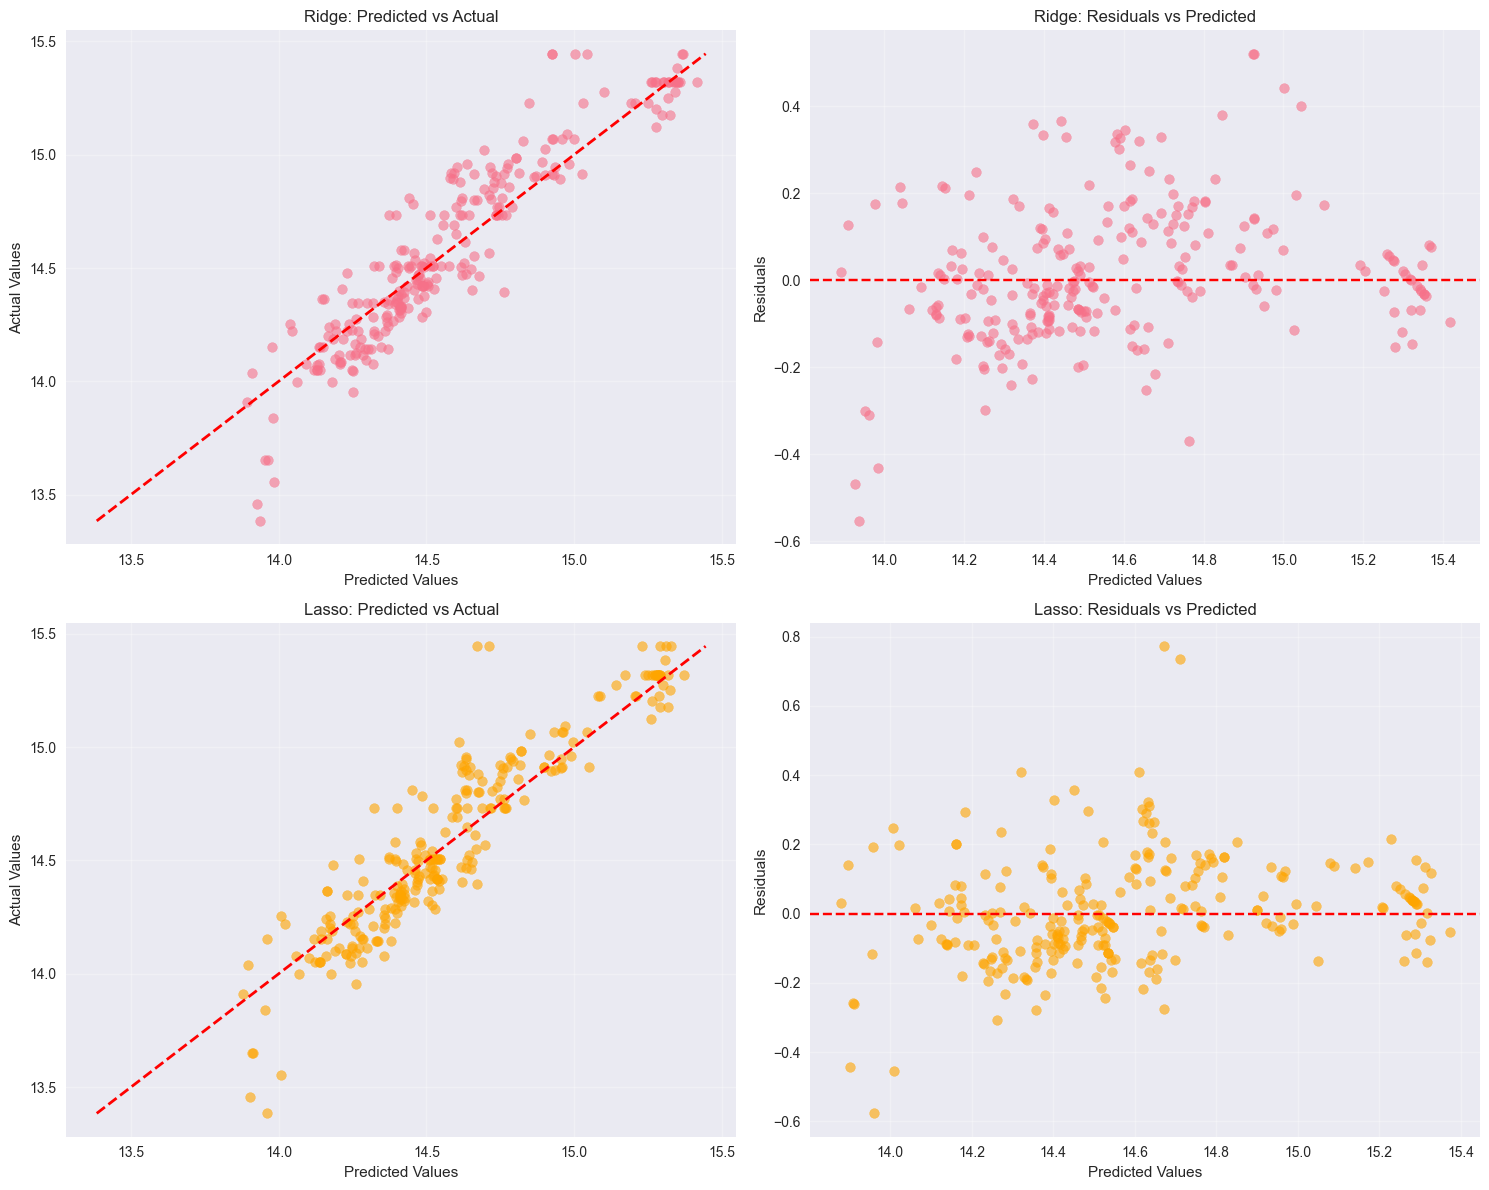

In [20]:
# Analisi dei residui
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Ridge residuals
ridge_residuals = y_test - ridge_results['predictions']

# Plot 1: Ridge - Predicted vs Actual
axes[0,0].scatter(ridge_results['predictions'], y_test, alpha=0.6)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Predicted Values')
axes[0,0].set_ylabel('Actual Values')
axes[0,0].set_title('Ridge: Predicted vs Actual')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Ridge - Residuals vs Predicted
axes[0,1].scatter(ridge_results['predictions'], ridge_residuals, alpha=0.6)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Ridge: Residuals vs Predicted')
axes[0,1].grid(True, alpha=0.3)

# Lasso residuals
lasso_residuals = y_test - lasso_results['predictions']

# Plot 3: Lasso - Predicted vs Actual
axes[1,0].scatter(lasso_results['predictions'], y_test, alpha=0.6, color='orange')
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1,0].set_xlabel('Predicted Values')
axes[1,0].set_ylabel('Actual Values')
axes[1,0].set_title('Lasso: Predicted vs Actual')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Lasso - Residuals vs Predicted
axes[1,1].scatter(lasso_results['predictions'], lasso_residuals, alpha=0.6, color='orange')
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Predicted Values')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Lasso: Residuals vs Predicted')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== FEATURE SELEZIONATE DA LASSO (16 su 290) ===

                                                                         Feature  Coefficient  Abs_Coefficient
                                                                    cruise_speed     0.267056         0.267056
                                                                     all_eng_roc     0.036879         0.036879
                                                                       max_speed     0.033296         0.033296
                                                                       wing_span     0.025052         0.025052
                                                                model_name_115TC    -0.020117         0.020117
                                                                  model_name_560     0.018370         0.018370
                                                       model_name_150 D,-E,-F,-G     0.006755         0.006755
                                                              

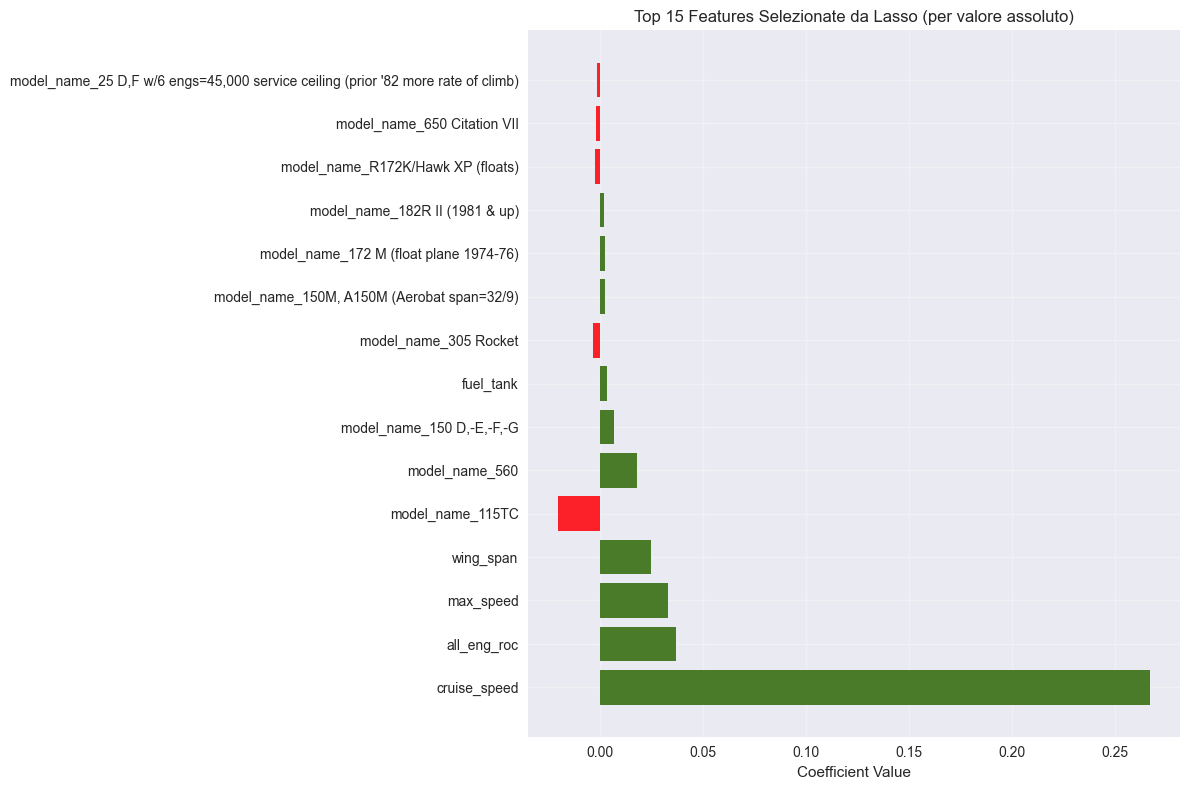

In [21]:
# Analisi delle feature selezionate da Lasso
feature_names = X.columns
selected_features = feature_names[final_coefs != 0]
selected_coefs = final_coefs[final_coefs != 0]

print(f"=== FEATURE SELEZIONATE DA LASSO ({len(selected_features)} su {len(feature_names)}) ===")
print()

# Ordina per valore assoluto del coefficiente
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': selected_coefs,
    'Abs_Coefficient': np.abs(selected_coefs)
}).sort_values('Abs_Coefficient', ascending=False)

print(feature_importance.to_string(index=False))

# Grafico delle feature più importanti (top 15)
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_features)), top_features['Coefficient'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Features Selezionate da Lasso (per valore assoluto)')
plt.grid(True, alpha=0.3)

# Colora le barre positive e negative
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
plt.gca().barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)

plt.tight_layout()
plt.show()

## CONFRONTO CON LINEAR REGRESSION (BASELINE)

=== CONFRONTO COMPLETO: LINEAR REGRESSION vs RIDGE vs LASSO ===
Metric          Linear Reg   Ridge        Lasso       
------------------------------------------------------------
MSE             0.0293       0.0249       0.0257      
RMSE            0.1713       0.1579       0.1604      
MAE             0.1249       0.1182       0.1192      
R²              0.8335       0.8584       0.8539      
Features        290          290          16          


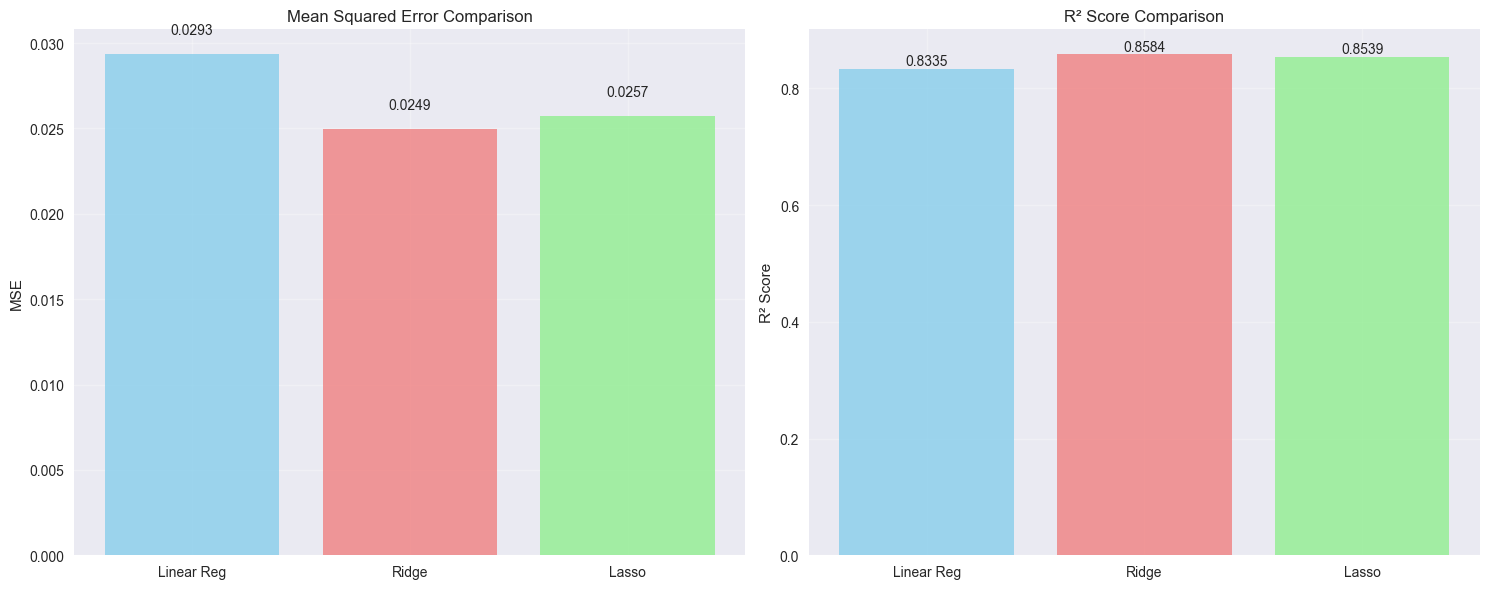

In [22]:
# Baseline: Linear Regression senza regolarizzazione
lr_pipe = make_pipeline(StandardScaler(), LinearRegression())
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)

# Calcola metriche per Linear Regression
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("=== CONFRONTO COMPLETO: LINEAR REGRESSION vs RIDGE vs LASSO ===")
print(f"{'Metric':<15} {'Linear Reg':<12} {'Ridge':<12} {'Lasso':<12}")
print("-" * 60)
print(f"{'MSE':<15} {lr_mse:<12.4f} {ridge_results['mse']:<12.4f} {lasso_results['mse']:<12.4f}")
print(f"{'RMSE':<15} {lr_rmse:<12.4f} {ridge_results['rmse']:<12.4f} {lasso_results['rmse']:<12.4f}")
print(f"{'MAE':<15} {lr_mae:<12.4f} {ridge_results['mae']:<12.4f} {lasso_results['mae']:<12.4f}")
print(f"{'R²':<15} {lr_r2:<12.4f} {ridge_results['r2']:<12.4f} {lasso_results['r2']:<12.4f}")
print(f"{'Features':<15} {X.shape[1]:<12} {X.shape[1]:<12} {lasso_results['n_features']:<12}")

# Grafico di confronto finale
models = ['Linear Reg', 'Ridge', 'Lasso']
mse_values = [lr_mse, ridge_results['mse'], lasso_results['mse']]
r2_values = [lr_r2, ridge_results['r2'], lasso_results['r2']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# MSE comparison
ax1.bar(models, mse_values, color=['skyblue', 'lightcoral', 'lightgreen'], alpha=0.8)
ax1.set_ylabel('MSE')
ax1.set_title('Mean Squared Error Comparison')
ax1.grid(True, alpha=0.3)
for i, v in enumerate(mse_values):
    ax1.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

# R² comparison
ax2.bar(models, r2_values, color=['skyblue', 'lightcoral', 'lightgreen'], alpha=0.8)
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score Comparison')
ax2.grid(True, alpha=0.3)
for i, v in enumerate(r2_values):
    ax2.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## CONCLUSIONI E SUMMARY

### Punti Chiave dell'Analisi:

1. **Preprocessing**: Utilizzo di dati con log-price e standardizzazione delle features
2. **Cross-validation**: Ottimizzazione degli iperparametri con 10-fold CV
3. **Confronto Multi-metrica**: MSE, RMSE, MAE, R² per valutazione completa
4. **Feature Selection**: Lasso ha selezionato automaticamente le feature più rilevanti
5. **Analisi Residui**: Valutazione della qualità delle predizioni

### Raccomandazioni:
- **Ridge**: Migliore per mantenere tutte le features con controllo della multicollinearità
- **Lasso**: Preferibile quando serve interpretabilità e selezione automatica delle features
- **Linear Regression**: Baseline di riferimento (spesso overfitting con molte features)